# Exploración del dataset

Exploración del dataset **TBX11K** (Liu et al., CVPR 2020) como punto de partida del proyecto.

Preguntas guía:
- ¿Cómo están organizadas las imágenes, las etiquetas y las anotaciones?
- ¿Qué imágenes tienen etiqueta utilizable para la tarea **TB vs no-TB**?
- ¿Qué formato tienen las imágenes (tamaño, canales, profundidad)?
- ¿Cómo se distribuyen las intensidades por clase y qué implica eso para la radiómica de primer orden?
- ¿Hay problemas de calidad (duplicados, anotaciones vacías) que afecten el muestreo del subconjunto?

Este notebook **solo lee** `data/raw/`; no escribe archivos.

### 1. Configuración del entorno

In [2]:
import hashlib
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

# Raíz del proyecto: funciona ejecutando desde la raíz o desde notebooks/
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw" / "TBX11K").exists())
DATA_DIR = ROOT / "data" / "raw" / "TBX11K"
IMG_DIR = DATA_DIR / "imgs"
LIST_DIR = DATA_DIR / "lists"
ANNO_DIR = DATA_DIR / "annotations"

SEED = 42
rng = np.random.default_rng(SEED)

# Clases con etiqueta pública (carpeta -> nombre legible)
CLASSES = {"tb": "TB", "health": "Sano", "sick": "Enfermo no-TB"}
CLASS_COLORS = {"tb": "#2a78d6", "health": "#eb6834", "sick": "#1baf7a"}

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c3",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": "#0b0b0b",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#ecebe7",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "legend.frameon": False,
})
pd.set_option("display.max_columns", 30)
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /home/julian/proyects/tuberculosis-lung-segmentation


### 2. Estructura del dataset

#### 2.1 Carpetas de imágenes

- `tb/`, `health/` y `sick/` son las imágenes propias de TBX11K.
- `extra/` contiene imágenes de otros datasets (DA/DB, Montgomery, Shenzhen).

#### 2.2 Índice de imágenes etiquetadas y particiones oficiales

In [3]:
def read_list(name):
    return set((LIST_DIR / name).read_text().split())

train_list, val_list, trainval_list = (read_list(f"TBX11K_{s}.txt") for s in ["train", "val", "trainval"])

index = pd.DataFrame(
    [{"image_id": p.stem, "rel_path": f"{c}/{p.name}", "source_class": c}
     for c in CLASSES for p in sorted((IMG_DIR / c).glob("*.png"))]
)
index["label"] = (index["source_class"] == "tb").astype(int)
index["official_split"] = np.where(index["rel_path"].isin(train_list), "train",
                          np.where(index["rel_path"].isin(val_list), "val", "none"))

Las 8400 imágenes de `tb/health/sick` coinciden exactamente con `TBX11K_trainval.txt`, y la partición oficial es 75/25 estratificada por clase. Para TB vs no-TB hay **800 positivos frente a 7600 negativos**.

#### 2.2 Anotaciones de TB (cajas)

In [4]:
xml_rows, box_rows = [], []
for xml_path in sorted((ANNO_DIR / "xml").glob("*.xml")):
    root = ET.parse(xml_path).getroot()
    objects = root.findall("object")
    xml_rows.append({
        "image_id": xml_path.stem,
        "orig_width": int(root.find("size/width").text),
        "orig_height": int(root.find("size/height").text),
        "n_boxes": len(objects),
        "categories": " + ".join(sorted({o.find("name").text for o in objects})) or "(sin cajas)",
    })
    box_rows += [{"image_id": xml_path.stem, "category": o.find("name").text} for o in objects]
xml_df, box_df = pd.DataFrame(xml_rows), pd.DataFrame(box_rows)

tb_ids = set(index.loc[index["label"] == 1, "image_id"])
print("XML:", len(xml_df), "| ¿un XML por cada imagen TB?:", set(xml_df["image_id"]) == tb_ids)
display(box_df["category"].value_counts().rename("cajas").to_frame())
display(xml_df["categories"].value_counts().rename("imagenes").to_frame())
display(xml_df["n_boxes"].value_counts().sort_index().rename("imagenes").rename_axis("cajas por imagen").to_frame())
print("Imágenes TB sin cajas:", xml_df.loc[xml_df["n_boxes"] == 0, "image_id"].tolist())

XML: 800 | ¿un XML por cada imagen TB?: True


,cajas
category,
ActiveTuberculosis,972
ObsoletePulmonaryTuberculosis,239


,imagenes
categories,
ActiveTuberculosis,630
ObsoletePulmonaryTuberculosis,139
ActiveTuberculosis + ObsoletePulmonaryTuberculosis,30
(sin cajas),1


,imagenes
cajas por imagen,
0,1
1,417
2,355
3,24
4,3


Imágenes TB sin cajas: ['tb1199']


- Solo las imágenes TB tienen anotaciones: **cajas de lesiones**, no máscaras de pulmón.
- La categoría `ObsoletePulmonaryTuberculosis` corresponde a TB latente. La clase TB mezcla TB activa y latente.
- Las radiografías originales tenían tamaños distintos y fueron **redimensionadas a 512×512** por los autores. La relación de aspecto original se perdió.

### 3. Exploración de imágenes

#### 3.1 Formato y estadísticas por imagen

Se recorren las 8400 imágenes etiquetadas. Por cada imagen se registran el formato, estadísticas de intensidad, el histograma de niveles de gris y un hash del contenido para detectar duplicados. De paso se acumulan la imagen promedio y la desviación estándar por clase.

In [6]:
stats_rows, histograms = [], np.zeros((len(index), 256), dtype=np.int64)
pix_sum = {c: np.zeros((512, 512)) for c in CLASSES}
pix_sq = {c: np.zeros((512, 512)) for c in CLASSES}

for i, row in enumerate(index.itertuples()):
    img = cv2.imread(str(IMG_DIR / row.rel_path), cv2.IMREAD_UNCHANGED)
    channels_equal = img.ndim == 2 or (np.array_equal(img[..., 0], img[..., 1])
                                       and np.array_equal(img[..., 1], img[..., 2]))
    gray = img if img.ndim == 2 else img[..., 0]  # los 3 canales son iguales (se verifica abajo)
    histograms[i] = np.bincount(gray.ravel(), minlength=256)
    pix_sum[row.source_class] += gray
    pix_sq[row.source_class] += gray.astype(np.float64) ** 2
    stats_rows.append({
        "shape": img.shape, "dtype": str(img.dtype), "channels_equal": channels_equal,
        "mean": gray.mean(), "std": gray.std(),
        "p01": np.percentile(gray, 1), "p99": np.percentile(gray, 99),
        "frac_black": (gray == 0).mean(), "frac_white": (gray == 255).mean(),
        "md5": hashlib.md5(gray.tobytes()).hexdigest(),
    })

stats = pd.concat([index, pd.DataFrame(stats_rows)], axis=1)
print("Formas:", Counter(stats["shape"]))
print("Tipos:", Counter(stats["dtype"]))
print("¿Canales RGB idénticos en todas?:", stats["channels_equal"].all())

Formas: Counter({(512, 512, 3): 8400})
Tipos: Counter({'uint8': 8400})
¿Canales RGB idénticos en todas?: True


Todas las imágenes miden 512×512, son `uint8` y se guardaron en RGB con los **tres canales idénticos**. Basta con leerlas en escala de grises (`cv2.IMREAD_GRAYSCALE`), sin perder información.

#### 3.2 Ejemplos por clase

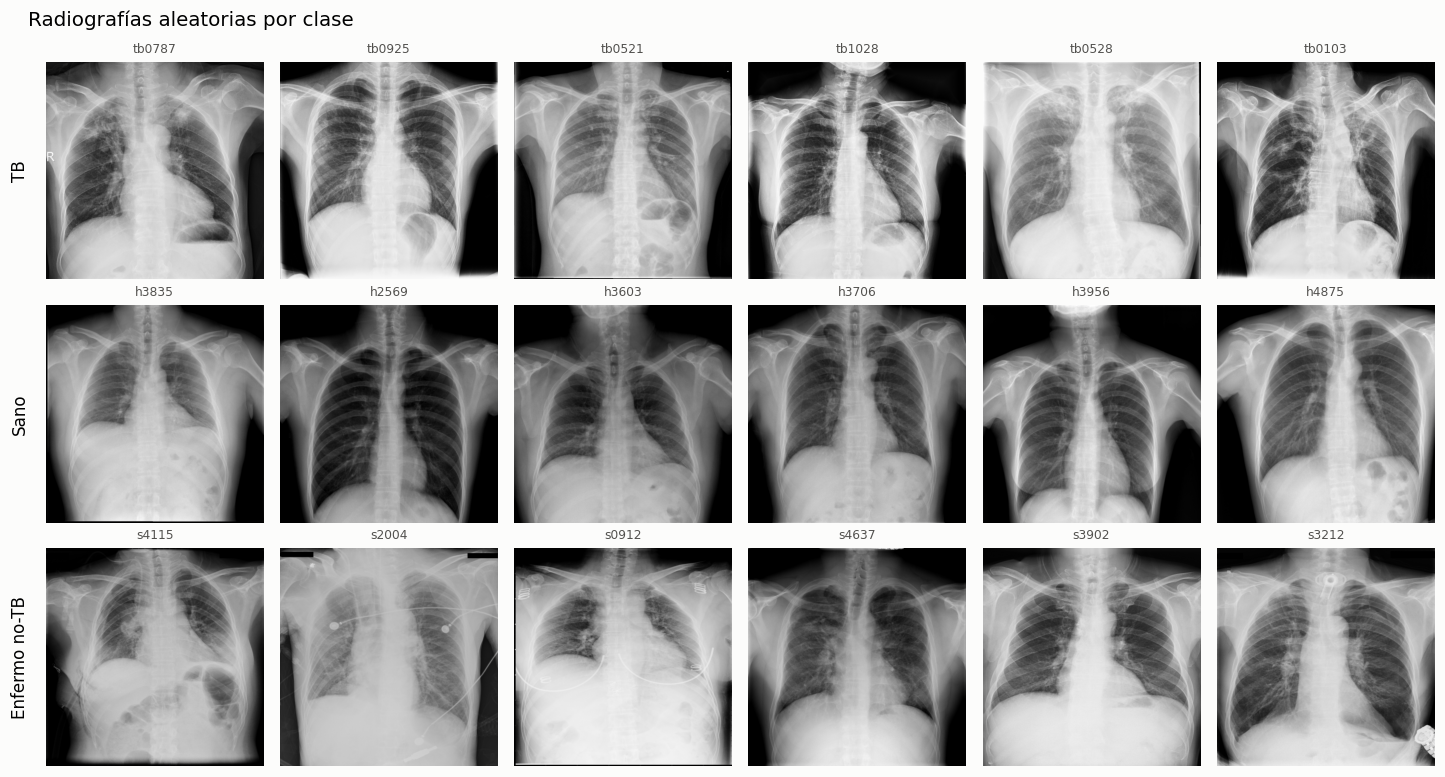

In [8]:
n_cols = 6
fig, axes = plt.subplots(len(CLASSES), n_cols, figsize=(2.2 * n_cols, 2.4 * len(CLASSES)))
for r, cls in enumerate(CLASSES):
    ids = rng.choice(index.loc[index["source_class"] == cls, "rel_path"], n_cols, replace=False)
    for c, rel in enumerate(ids):
        ax = axes[r, c]
        ax.imshow(cv2.imread(str(IMG_DIR / rel), cv2.IMREAD_GRAYSCALE), cmap="gray", vmin=0, vmax=255)
        ax.set_title(Path(rel).stem, fontsize=8, color="#52514e")
        ax.axis("off")
    axes[r, 0].text(-40, 256, CLASSES[cls], rotation=90, va="center", ha="right", fontsize=11)
fig.suptitle("Radiografías aleatorias por clase", x=0.02, ha="left", fontsize=13)
fig.tight_layout()
plt.show()

#### 3.3 Cajas de lesiones TB

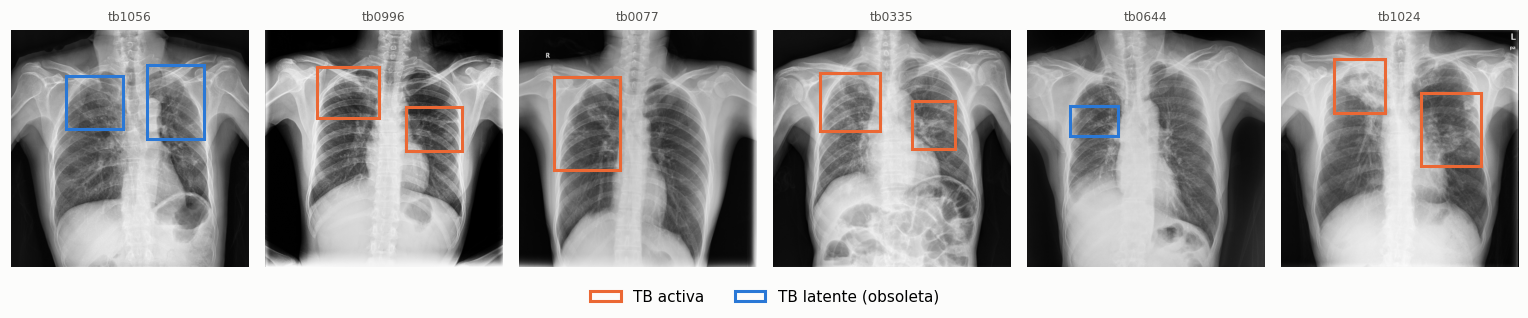

In [9]:
# El JSON COCO ya tiene las cajas en la escala 512x512
coco = __import__("json").loads((ANNO_DIR / "json" / "TBX11K_trainval_only_tb.json").read_text())
cat_names = {c["id"]: c["name"] for c in coco["categories"]}
img_files = {im["id"]: im["file_name"] for im in coco["images"]}
boxes_by_file = defaultdict(list)
for a in coco["annotations"]:
    boxes_by_file[img_files[a["image_id"]]].append((a["bbox"], cat_names[a["category_id"]]))

BOX_COLORS = {"ActiveTuberculosis": "#eb6834", "ObsoletePulmonaryTuberculosis": "#2a78d6"}
sample = rng.choice(sorted(boxes_by_file), 6, replace=False)
fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
for ax, fname in zip(axes, sample):
    ax.imshow(cv2.imread(str(IMG_DIR / fname), cv2.IMREAD_GRAYSCALE), cmap="gray", vmin=0, vmax=255)
    for (x, y, w, h), cat in boxes_by_file[fname]:
        ax.add_patch(Rectangle((x, y), w, h, fill=False, lw=2, ec=BOX_COLORS[cat]))
    ax.set_title(Path(fname).stem, fontsize=8, color="#52514e")
    ax.axis("off")
handles = [Rectangle((0, 0), 1, 1, fill=False, lw=2, ec=col) for col in BOX_COLORS.values()]
fig.legend(handles, ["TB activa", "TB latente (obsoleta)"], loc="lower center", ncol=2)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

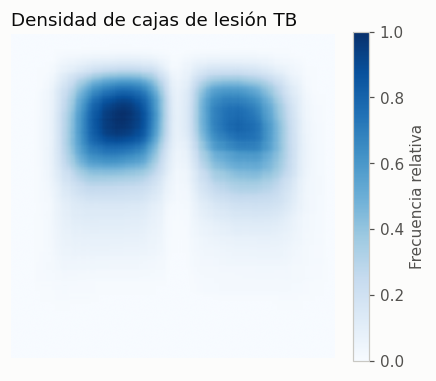

In [10]:
# Mapa de densidad: ¿dónde se ubican las lesiones? (fracción de cajas que cubre cada píxel)
heat = np.zeros((512, 512))
for items in boxes_by_file.values():
    for (x, y, w, h), _ in items:
        heat[int(y):int(np.ceil(y + h)), int(x):int(np.ceil(x + w))] += 1
fig, ax = plt.subplots(figsize=(4.2, 4.2))
im = ax.imshow(heat / heat.max(), cmap="Blues", vmin=0, vmax=1)
ax.set_title("Densidad de cajas de lesión TB", loc="left")
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="Frecuencia relativa")
plt.show()

Las lesiones se concentran en los **campos pulmonares**, sobre todo en los lóbulos superiores.

#### 3.4 Distribución de intensidades por clase

Las características radiómicas de primer orden (media, percentiles, entropía, etc.) dependen directamente de estas distribuciones.

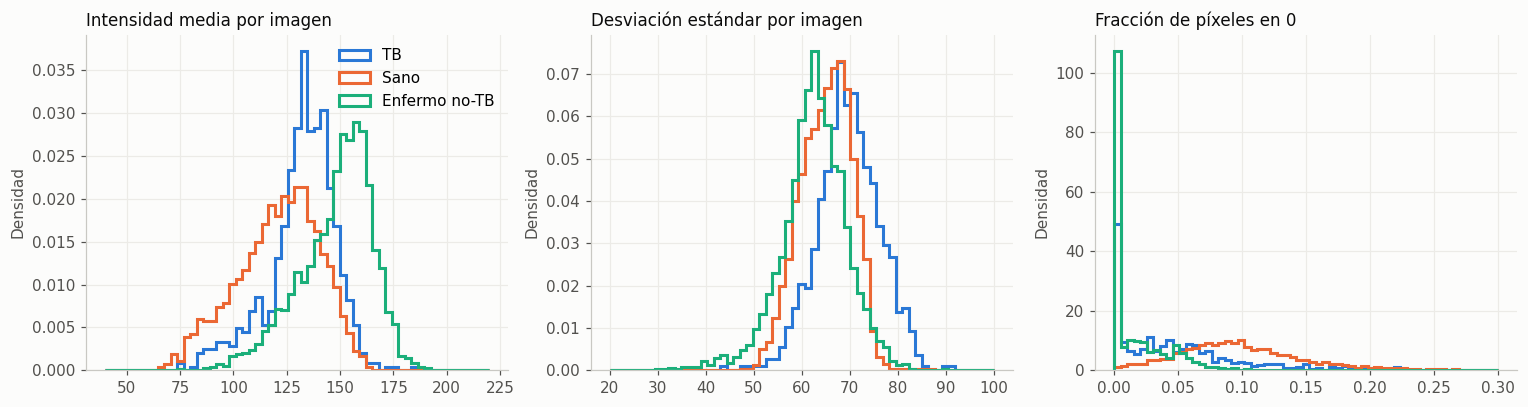

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
panels = [("mean", "Intensidad media por imagen", np.linspace(40, 220, 60)),
          ("std", "Desviación estándar por imagen", np.linspace(20, 100, 60)),
          ("frac_black", "Fracción de píxeles en 0", np.linspace(0, 0.3, 60))]
for ax, (col, title, bins) in zip(axes, panels):
    for cls, name in CLASSES.items():
        ax.hist(stats.loc[stats["source_class"] == cls, col], bins=bins, density=True,
                histtype="step", lw=2, color=CLASS_COLORS[cls], label=name)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel("Densidad")
axes[0].legend()
fig.tight_layout()
plt.show()

#### 3.5 Imagen promedio y variabilidad espacial por clase

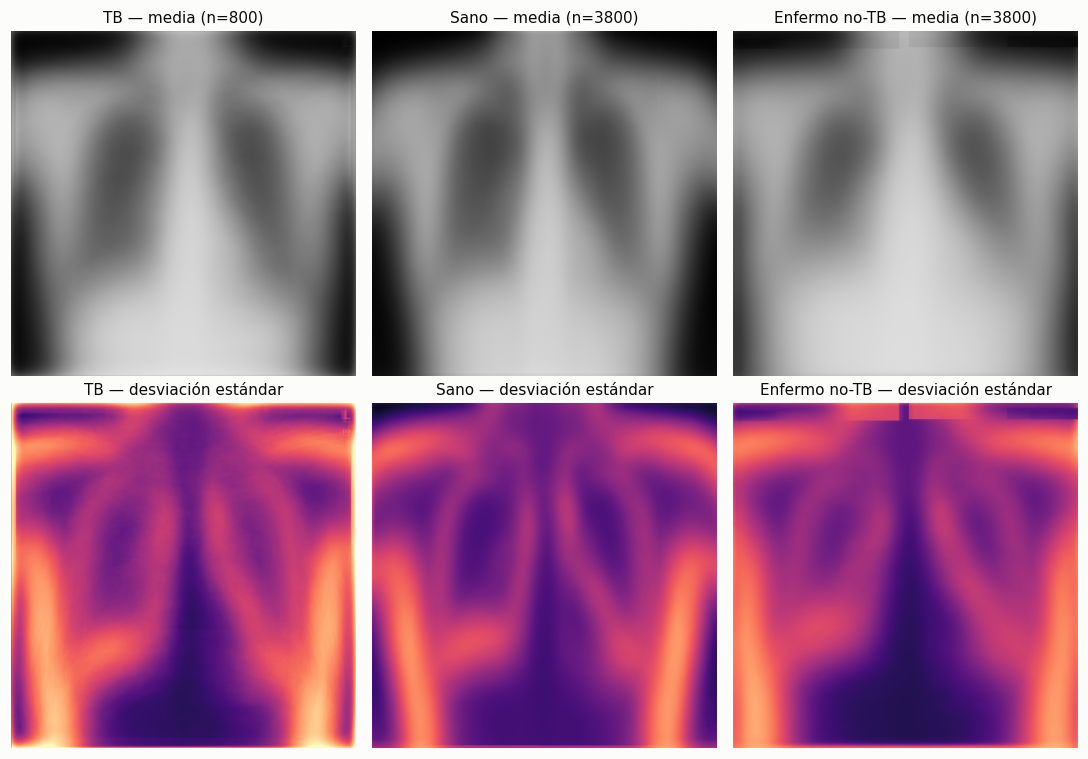

In [13]:
fig, axes = plt.subplots(2, len(CLASSES), figsize=(10, 7))
for c, cls in enumerate(CLASSES):
    n = (index["source_class"] == cls).sum()
    mean_img = pix_sum[cls] / n
    std_img = np.sqrt(np.maximum(pix_sq[cls] / n - mean_img ** 2, 0))
    axes[0, c].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
    axes[0, c].set_title(f"{CLASSES[cls]} — media (n={n})", fontsize=10)
    axes[1, c].imshow(std_img, cmap="magma", vmin=0, vmax=90)
    axes[1, c].set_title(f"{CLASSES[cls]} — desviación estándar", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
fig.tight_layout()
plt.show()

La imagen promedio muestra dónde caen los campos pulmonares y cuánto varía su posición entre radiografías. Donde el mapa de desviación estándar tiene valores altos, los bordes del pulmón cambian de lugar de una imagen a otra. Esto es relevante para **generar automáticamente las cajas-prompt de MedSAM** y para el QC de las máscaras.

#### 3.6 Imágenes duplicadas

In [14]:
dup_groups = [g["image_id"].tolist() for _, g in stats.groupby("md5") if len(g) > 1]
dup_df = pd.DataFrame({"grupo": range(len(dup_groups)), "image_ids": dup_groups})
dup_df["clases"] = dup_df["image_ids"].map(lambda ids: " + ".join(sorted({index.set_index("image_id").loc[i, "source_class"] for i in ids})))
print("Grupos de imágenes idénticas (píxel a píxel):", len(dup_groups))
display(dup_df["clases"].value_counts().rename("grupos").to_frame())
display(dup_df.head(10))

extra_copies = stats.duplicated("md5").groupby(stats["source_class"]).sum()
unique_per_class = stats.drop_duplicates("md5")["source_class"].value_counts().loc[list(CLASSES)]
display(pd.DataFrame({"imagenes": stats["source_class"].value_counts().loc[list(CLASSES)],
                      "copias_repetidas": extra_copies.loc[list(CLASSES)],
                      "unicas": unique_per_class}))

# Pares duplicados repartidos en particiones oficiales distintas
split_by_id = index.set_index("image_id")["official_split"]
cross = sum(len({split_by_id[i] for i in ids}) > 1 for ids in dup_groups)
print("Grupos repartidos entre train y val oficiales:", cross)

Grupos de imágenes idénticas (píxel a píxel): 126


,grupos
clases,
sick,126


,grupo,image_ids,clases
0,0,"[s2669, s4818]",sick
1,1,"[s1433, s1983]",sick
2,2,"[s1463, s2801]",sick
3,3,"[s4125, s4217]",sick
4,4,"[s3503, s4248]",sick
5,5,"[s0583, s3878]",sick
6,6,"[s1004, s2904]",sick
7,7,"[s0647, s4415]",sick
8,8,"[s0199, s2193]",sick
9,9,"[s4402, s4862]",sick


,imagenes,copias_repetidas,unicas
source_class,,,
tb,800,0,800
health,3800,0,3800
sick,3800,126,3674


Grupos repartidos entre train y val oficiales: 38


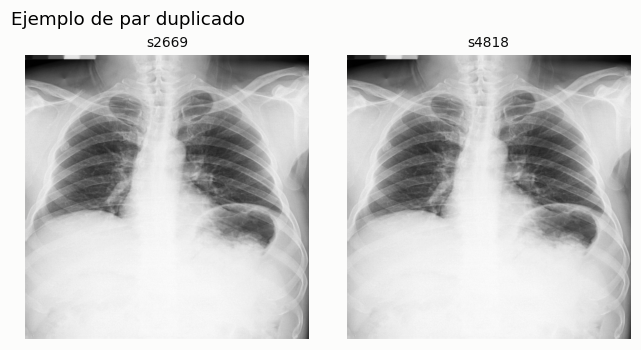

In [15]:
a, b = dup_groups[0]
fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))
for ax, image_id in zip(axes, (a, b)):
    rel = index.set_index("image_id").loc[image_id, "rel_path"]
    ax.imshow(cv2.imread(str(IMG_DIR / rel), cv2.IMREAD_GRAYSCALE), cmap="gray")
    ax.set_title(image_id, fontsize=9)
    ax.axis("off")
fig.suptitle("Ejemplo de par duplicado", x=0.02, ha="left")
fig.tight_layout()
plt.show()

### 4. Conclusiones e implicaciones para el proyecto

**Datos utilizables**
- Hay **8400 imágenes con etiqueta**: 800 TB, 3800 sanas y 3800 enfermas no-TB. Coinciden exactamente con `TBX11K_trainval.txt`. Las imágenes de `test/` (sin etiquetas) y `extra/` (otras fuentes) quedan fuera.
- La etiqueta sale de la carpeta. La clase TB mezcla TB activa y latente (30 imágenes tienen ambas). `tb1199` es TB pero no tiene cajas, lo que no afecta la clasificación.

**Formato**
- Todas son 512×512 `uint8` y tienen los 3 canales RGB idénticos, así que se cargan con `cv2.IMREAD_GRAYSCALE`, **con la misma función para todos los métodos**.
- Los originales tenían tamaños distintos y fueron redimensionados a un cuadrado. Las proporciones no se conservan.

**Calidad: duplicados**
- Hay **126 pares de imágenes idénticas píxel a píxel, todos dentro de `sick`**; quedan 3674 únicas. 38 de esos pares incluso quedan repartidos entre el train y el val oficiales.
- ⇒ Al construir `subset.csv` hay que **eliminar duplicados (por hash) antes de muestrear** las 400 imágenes de `sick`. Si no, una misma imagen puede caer en dos folds y generar fuga de información en la validación cruzada.

**Diferencias de adquisición entre clases (posibles confusores)**
- La intensidad media difiere mucho entre clases: sanas ≈ 121, TB ≈ 132 y enfermas no-TB ≈ 148. También difiere la fracción de fondo negro: ≈ 9.9 % en sanas, 4.8 % en TB y 1.7 % en enfermas.

**Implicaciones para la segmentación**
- Las cajas de lesión TB se concentran en los **campos pulmonares superiores**.
- La imagen promedio muestra una ubicación pulmonar bastante consistente, pero con variación visible en los bordes (mapa de desviación estándar). Si las cajas-prompt de MedSAM se derivan de una posición promedio, necesitan un **margen generoso**.